# Model Analysis: PNN

Diagnostic analysis of the trained PNN (Probabilistic Neural Network) model (§5.1 of the report):
1. Distribution of predicted parameters $\mu$, $\sigma$, $\alpha$ — verify $\sigma > 0$.
2. NLL anomaly score distribution.
3. Spoofing gain $G_t$ distribution and prevalence of $G_t > 0$.
4. $\delta_b$ sensitivity sweep for the spoofing gain computation.
5. Score distribution across test days.

In [1]:
import os, sys, glob, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences, load_processed
from detection.models.pnn import PNN, SkewedGaussianNLL
from detection.spoofing.gain import calculate_expected_cost, compute_spoofing_gains_batch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
TRAIN_YEAR = "2017"  # "2015" or "2017"
RESULTS_DIR = os.path.join("..", "results", str(TRAIN_YEAR))

SEQ_LENGTH = 25
BATCH_SIZE = 512

LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [("bid","price"),("bid","volume"),("ask","price"),("ask","volume")]
]

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILES = [FILES[22], FILES[23], FILES[24], FILES[25], FILES[26]]
print(f"Training year : {TRAIN_YEAR}")
print(f"Results dir   : {RESULTS_DIR}")
print(f"Test files    : {[os.path.basename(f) for f in TEST_FILES]}")

Training year : 2017
Results dir   : ..\results\2017
Test files    : ['2010-02-02-TOTF.PA-book.parquet', '2010-02-03-TOTF.PA-book.parquet', '2010-02-04-TOTF.PA-book.parquet', '2010-02-05-TOTF.PA-book.parquet', '2010-02-08-TOTF.PA-book.parquet']


In [3]:
# Load feature names
feat_path = os.path.join(RESULTS_DIR, "pnn_features.txt")
with open(feat_path) as f:
    feat_names = [line.strip() for line in f if line.strip()]
num_features = len(feat_names)
print(f"Features: {num_features}")

# Load scaler
scaler_path = os.path.join(RESULTS_DIR, "pnn_scaler.pkl")
scaler = joblib.load(scaler_path)

# Load PNN model (input = last timestep only)
model = PNN(input_dim=num_features, hidden_dim=64).to(DEVICE)
weights_path = os.path.join(RESULTS_DIR, "pnn_weights.pth")
model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
model.eval()
print("PNN model loaded.")

# --- Run inference on first test file ---
TEST_FILE = TEST_FILES[0]
df_test, features_test = load_processed(TEST_FILE, "xltime", LOB_COLUMNS)
feat_df = features_test.copy()
for col in feat_names:
    if col not in feat_df.columns:
        feat_df[col] = 0.0
feat_df = feat_df[feat_names]

scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
sequences = create_sequences(scaled, SEQ_LENGTH)

all_mu, all_sigma, all_alpha = [], [], []
with torch.no_grad():
    for start in range(0, len(sequences), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(sequences))
        x = torch.tensor(sequences[start:end, -1, :], dtype=torch.float32).to(DEVICE)
        mu, sigma, alpha = model(x)
        all_mu.append(mu.cpu().numpy())
        all_sigma.append(sigma.cpu().numpy())
        all_alpha.append(alpha.cpu().numpy())

mu_arr = np.concatenate(all_mu).flatten()
sigma_arr = np.concatenate(all_sigma).flatten()
alpha_arr = np.concatenate(all_alpha).flatten()
print(f"Predictions: {len(mu_arr)} events on {os.path.basename(TEST_FILE)}")

Features: 89
PNN model loaded.
Predictions: 213138 events on 2010-02-02-TOTF.PA-book.parquet


## 1. Predicted Distribution Parameters ($\mu$, $\sigma$, $\alpha$)

Verify that the PNN outputs sensible distribution parameters:
- $\sigma > 0$ (no collapse) — enforced by Softplus + $\epsilon$
- $\alpha$ (skewness) shows variation, not constant
- $\mu$ (location) is centered near observed log-returns

=== Predicted Parameter Statistics ===
  μ (location)   : mean=-0.000349  std=0.000774  min=-0.028773  max=0.035760  median=-0.000345
  σ (scale)      : mean=0.000328  std=0.000088  min=0.000086  max=0.002109  median=0.000315
  α (skewness)   : mean=-0.680765  std=0.156960  min=-1.627558  max=0.535762  median=-0.683488

  σ > 0 check   : min σ = 8.58e-05 ✓
  σ near-zero   : 0.00% of samples have σ < 1e-4


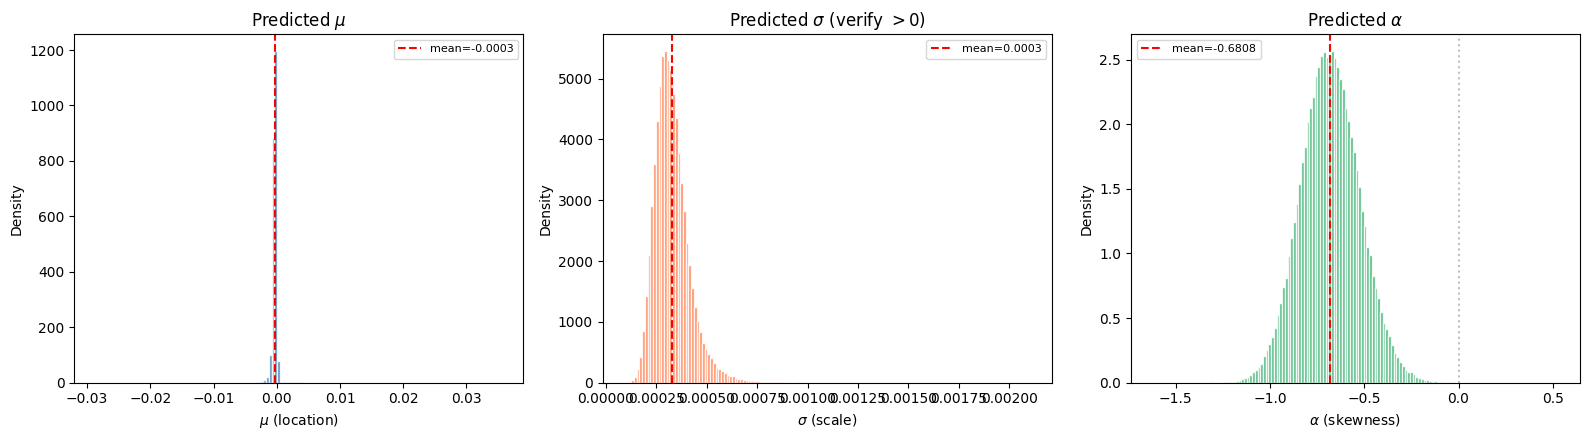

In [4]:
print("=== Predicted Parameter Statistics ===")
for name, arr in [("μ (location)", mu_arr), ("σ (scale)", sigma_arr), ("α (skewness)", alpha_arr)]:
    print(f"  {name:15s}: mean={arr.mean():.6f}  std={arr.std():.6f}  "
          f"min={arr.min():.6f}  max={arr.max():.6f}  median={np.median(arr):.6f}")

print(f"\n  σ > 0 check   : min σ = {sigma_arr.min():.2e} {'✓' if sigma_arr.min() > 0 else '✗ COLLAPSED'}")
print(f"  σ near-zero   : {100*np.mean(sigma_arr < 1e-4):.2f}% of samples have σ < 1e-4")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(mu_arr, bins=150, color="steelblue", edgecolor="white", alpha=0.85, density=True)
axes[0].set_xlabel("$\\mu$ (location)")
axes[0].set_ylabel("Density")
axes[0].set_title("Predicted $\\mu$")
axes[0].axvline(mu_arr.mean(), color="red", linestyle="--", label=f"mean={mu_arr.mean():.4f}")
axes[0].legend(fontsize=8)

axes[1].hist(sigma_arr, bins=150, color="coral", edgecolor="white", alpha=0.85, density=True)
axes[1].set_xlabel("$\\sigma$ (scale)")
axes[1].set_ylabel("Density")
axes[1].set_title("Predicted $\\sigma$ (verify $> 0$)")
axes[1].axvline(sigma_arr.mean(), color="red", linestyle="--", label=f"mean={sigma_arr.mean():.4f}")
axes[1].legend(fontsize=8)

axes[2].hist(alpha_arr, bins=150, color="mediumseagreen", edgecolor="white", alpha=0.85, density=True)
axes[2].set_xlabel("$\\alpha$ (skewness)")
axes[2].set_ylabel("Density")
axes[2].set_title("Predicted $\\alpha$")
axes[2].axvline(0, color="gray", linestyle=":", alpha=0.5)
axes[2].axvline(alpha_arr.mean(), color="red", linestyle="--", label=f"mean={alpha_arr.mean():.4f}")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2. NLL Anomaly Score

The per-sample negative log-likelihood $-\ln f(y_t \mid \mu_t, \sigma_t, \alpha_t)$ under the predicted skew-normal distribution.
High NLL = the realised price move was unlikely under the model.

=== NLL Anomaly Score ===
  Samples   : 213138
  Mean NLL  : -4.3436
  Std NLL   : 4.4686
  Min NLL   : -8.0875
  Max NLL   : 23.0259
  P95 NLL   : 2.3270
  P99 NLL   : 23.0259


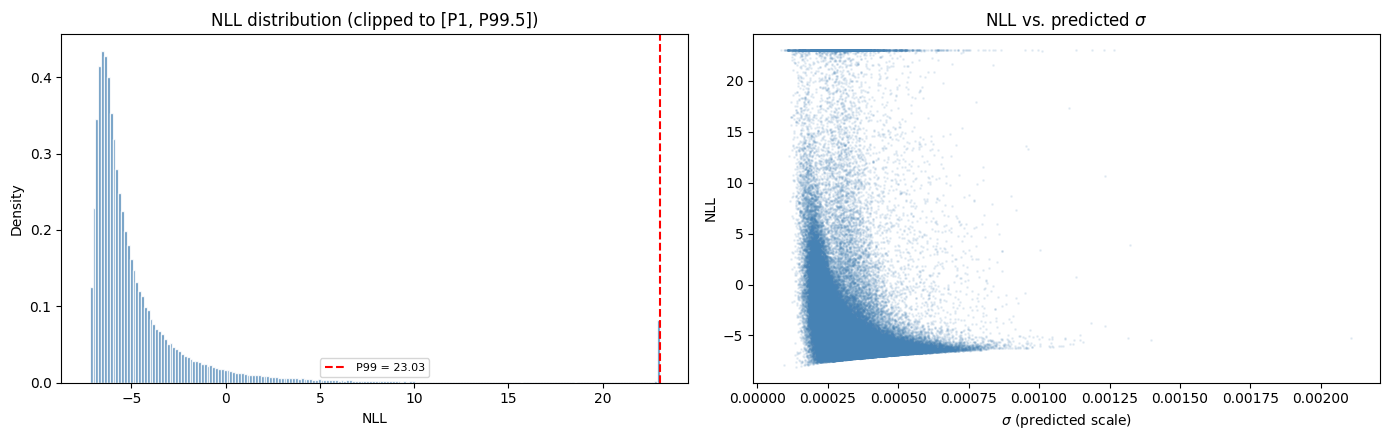

In [5]:
# Compute NLL on test data
# Extract actual log returns from the target column
target_col = "log_return"
target_idx = feat_names.index(target_col)
# Raw (pre-scaling) log returns aligned with sequences
y_raw = features_test[feat_names].values[SEQ_LENGTH:SEQ_LENGTH + len(mu_arr), target_idx].astype(np.float32)

# Compute per-sample NLL
nll_criterion = SkewedGaussianNLL()
with torch.no_grad():
    y_t = torch.tensor(y_raw).unsqueeze(1)
    mu_t = torch.tensor(mu_arr).unsqueeze(1)
    sigma_t = torch.tensor(sigma_arr).unsqueeze(1)
    alpha_t = torch.tensor(alpha_arr).unsqueeze(1)

    z = (y_t - mu_t) / sigma_t
    phi_z = (1.0 / math.sqrt(2 * math.pi)) * torch.exp(-0.5 * z**2)
    Phi_az = 0.5 * (1 + torch.erf(alpha_t * z / math.sqrt(2)))
    pdf = (2.0 / sigma_t) * phi_z * Phi_az
    nll = -torch.log(pdf + 1e-10).squeeze().numpy()

print("=== NLL Anomaly Score ===")
print(f"  Samples   : {len(nll)}")
print(f"  Mean NLL  : {nll.mean():.4f}")
print(f"  Std NLL   : {nll.std():.4f}")
print(f"  Min NLL   : {nll.min():.4f}")
print(f"  Max NLL   : {nll.max():.4f}")
print(f"  P95 NLL   : {np.percentile(nll, 95):.4f}")
print(f"  P99 NLL   : {np.percentile(nll, 99):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

p1, p99 = np.percentile(nll, [1, 99.5])
axes[0].hist(nll, bins=200, color="steelblue", edgecolor="white", alpha=0.85, density=True,
             range=(p1, p99))
axes[0].set_xlabel("NLL")
axes[0].set_ylabel("Density")
axes[0].set_title("NLL distribution (clipped to [P1, P99.5])")
axes[0].axvline(np.percentile(nll, 99), color="red", linestyle="--", label=f"P99 = {np.percentile(nll, 99):.2f}")
axes[0].legend(fontsize=8)

# NLL vs sigma
axes[1].scatter(sigma_arr, nll, s=1, alpha=0.1, color="steelblue")
axes[1].set_xlabel("$\\sigma$ (predicted scale)")
axes[1].set_ylabel("NLL")
axes[1].set_title("NLL vs. predicted $\\sigma$")

plt.tight_layout()
plt.show()

## 3. Spoofing Gain Distribution

The detection score for PNN is the **expected spoofing gain** $G_t = C(\text{no spoof}) - C(\text{spoof})$.
Log-return parameters are converted to EUR via $\Delta p \approx r \cdot p_\text{mid}$. A sample is flagged anomalous when $G_t > 0$.

=== Spoofing Gain (G_t) on 2010-02-02-TOTF.PA-book.parquet ===
  Samples        : 212672 (of 213138)
  Mean           : -71.683354 EUR
  Std            : 69.149684 EUR
  Min / Max      : -5546.661806 / 0.000000 EUR
  G_t > 0        : 217 (0.10%) → flagged anomalous


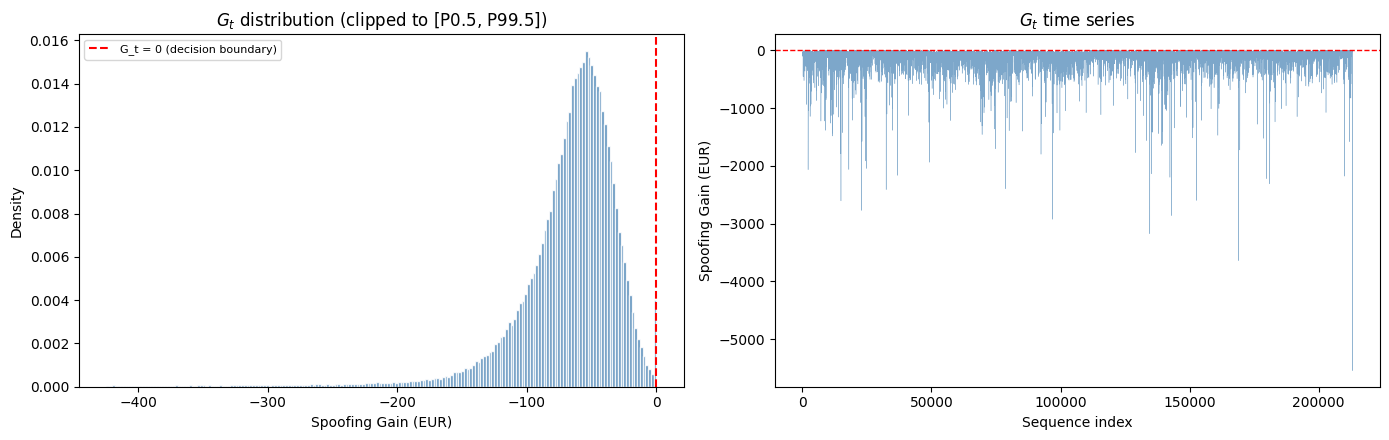

In [8]:
# Spoofing parameters (matching test.py)
SPOOF_Q = 4500
SPOOF_q = 100
SPOOF_DELTA_A = 0.0
SPOOF_DELTA_B = 0.01
SPOOF_FEES = {"maker": 0.0, "taker": 0.0008}

# Extract spread and mid-price for the test file
spread_raw = (df_test["ask-price-1"] - df_test["bid-price-1"]).values
mid_price = 0.5 * (df_test["ask-price-1"] + df_test["bid-price-1"]).values

spread_seq = np.abs(spread_raw[SEQ_LENGTH:SEQ_LENGTH + len(mu_arr)])
mid_seq = mid_price[SEQ_LENGTH:SEQ_LENGTH + len(mu_arr)]
spread_seq = np.where(spread_seq > 0, spread_seq, 1e-4)

# Convert log-return params → EUR
mu_eur = mu_arr * mid_seq
sigma_eur = sigma_arr * mid_seq

# Compute spoofing gains
gains = compute_spoofing_gains_batch(
    mu_eur, sigma_eur, alpha_arr, spread_seq,
    delta_a=SPOOF_DELTA_A, delta_b=SPOOF_DELTA_B,
    Q=SPOOF_Q, q=SPOOF_q,
    fees=SPOOF_FEES, side="ask",
)

# Filter NaNs produced by extreme parameter combinations
n_nan = np.isnan(gains).sum()
if n_nan > 0:
    print(f"  WARNING: {n_nan} NaN gains ({100*n_nan/len(gains):.2f}%) — filtering out")
gains_clean = gains[np.isfinite(gains)]

n_pos = np.sum(gains_clean > 0)
print(f"=== Spoofing Gain (G_t) on {os.path.basename(TEST_FILE)} ===")
print(f"  Samples        : {len(gains_clean)} (of {len(gains)})")
print(f"  Mean           : {gains_clean.mean():.6f} EUR")
print(f"  Std            : {gains_clean.std():.6f} EUR")
print(f"  Min / Max      : {gains_clean.min():.6f} / {gains_clean.max():.6f} EUR")
print(f"  G_t > 0        : {n_pos} ({100*n_pos/len(gains_clean):.2f}%) → flagged anomalous")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Full distribution
p1, p99 = np.nanpercentile(gains_clean, [0.5, 99.5])
axes[0].hist(gains_clean, bins=200, color="steelblue", edgecolor="white", alpha=0.85, density=True,
             range=(p1, p99))
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="G_t = 0 (decision boundary)")
axes[0].set_xlabel("Spoofing Gain (EUR)")
axes[0].set_ylabel("Density")
axes[0].set_title("$G_t$ distribution (clipped to [P0.5, P99.5])")
axes[0].legend(fontsize=8)

# Time series (plot original gains; NaN gaps will show as breaks)
axes[1].plot(gains, linewidth=0.3, alpha=0.7, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Sequence index")
axes[1].set_ylabel("Spoofing Gain (EUR)")
axes[1].set_title("$G_t$ time series")

plt.tight_layout()
plt.show()

## 4. $\delta_b$ Sensitivity Sweep

How does the spoofing gain change as a function of the spoofing order distance $\delta_b$?
Sweep $\delta_b \in [0, 0.05]$ with all other parameters fixed.

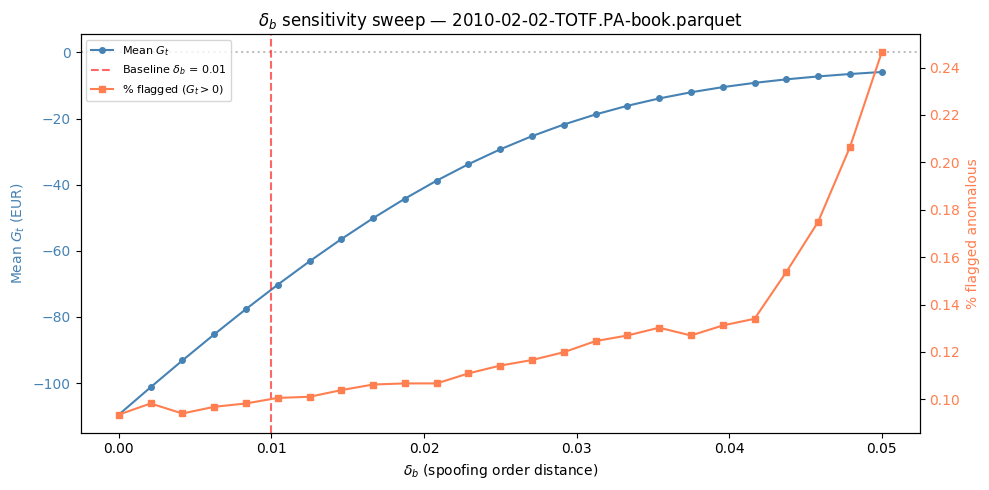


Baseline δ_b = 0.01:  mean G_t = -70.231641,  flagged = 0.10%


In [9]:
delta_b_values = np.linspace(0.0, 0.05, 25)
mean_gains = []
pct_positive = []

for db in delta_b_values:
    g = compute_spoofing_gains_batch(
        mu_eur, sigma_eur, alpha_arr, spread_seq,
        delta_a=SPOOF_DELTA_A, delta_b=db,
        Q=SPOOF_Q, q=SPOOF_q,
        fees=SPOOF_FEES, side="ask",
    )
    g_clean = g[np.isfinite(g)]
    mean_gains.append(np.nanmean(g_clean) if len(g_clean) > 0 else 0.0)
    pct_positive.append(100 * np.mean(g_clean > 0) if len(g_clean) > 0 else 0.0)

fig, ax1 = plt.subplots(figsize=(10, 5))

color1, color2 = "steelblue", "coral"
ax1.plot(delta_b_values, mean_gains, "o-", color=color1, markersize=4, label="Mean $G_t$")
ax1.set_xlabel("$\\delta_b$ (spoofing order distance)")
ax1.set_ylabel("Mean $G_t$ (EUR)", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax1.axvline(SPOOF_DELTA_B, color="red", linestyle="--", alpha=0.6, label=f"Baseline $\\delta_b$ = {SPOOF_DELTA_B}")

ax2 = ax1.twinx()
ax2.plot(delta_b_values, pct_positive, "s-", color=color2, markersize=4, label="% flagged ($G_t > 0$)")
ax2.set_ylabel("% flagged anomalous", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.title(f"$\\delta_b$ sensitivity sweep — {os.path.basename(TEST_FILE)}")
plt.tight_layout()
plt.show()

print(f"\nBaseline δ_b = {SPOOF_DELTA_B}:  mean G_t = {mean_gains[np.argmin(np.abs(delta_b_values - SPOOF_DELTA_B))]:.6f},  "
      f"flagged = {pct_positive[np.argmin(np.abs(delta_b_values - SPOOF_DELTA_B))]:.2f}%")

## 5. Score Distribution Across Test Days

Run PNN + spoofing-gain scoring on all test files. Aggregate statistics per day.

                            Day      N  NaN    Mean G_t    Std G_t  Max G_t  Flagged Rate (%)
2010-02-02-TOTF.PA-book.parquet 212672  466  -71.683354  69.149684 0.000000      217     0.10
2010-02-03-TOTF.PA-book.parquet 220582  395 -105.101441 107.849334 0.000000       87     0.04
2010-02-04-TOTF.PA-book.parquet 273787  484 -103.439066 127.988118 0.000000      128     0.05
2010-02-05-TOTF.PA-book.parquet 371390  387 -121.057615 177.167727 0.000000      374     0.10
2010-02-08-TOTF.PA-book.parquet 265243  333  -91.456415 102.343888 0.000000      197     0.07

Aggregate: 1343674 finite samples, 1003 flagged (0.07%)

Aggregate: 1343674 samples, 1003 flagged (0.07%)


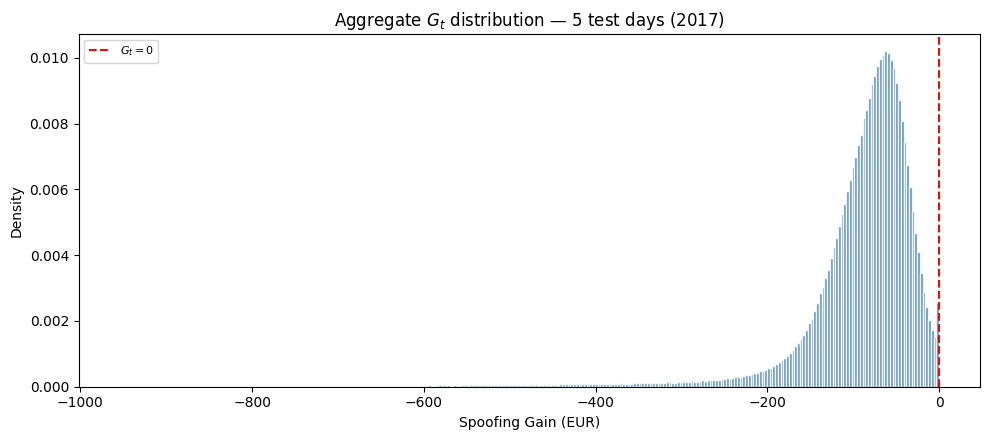

In [10]:
day_results = []
all_gains_agg = []

for tf in TEST_FILES:
    day_name = os.path.basename(tf)
    df_d, feat_d = load_processed(tf, "xltime", LOB_COLUMNS)
    for c in feat_names:
        if c not in feat_d.columns:
            feat_d[c] = 0.0
    feat_d = feat_d[feat_names]
    sc = scaler.transform(feat_d.values.astype(np.float32)).astype(np.float32)
    seqs = create_sequences(sc, SEQ_LENGTH)
    if len(seqs) == 0:
        continue

    # PNN inference
    _mu, _sig, _alp = [], [], []
    model.eval()
    with torch.no_grad():
        for s in range(0, len(seqs), BATCH_SIZE):
            e = min(s + BATCH_SIZE, len(seqs))
            x = torch.tensor(seqs[s:e, -1, :], dtype=torch.float32).to(DEVICE)
            m, si, a = model(x)
            _mu.append(m.cpu().numpy().flatten())
            _sig.append(si.cpu().numpy().flatten())
            _alp.append(a.cpu().numpy().flatten())
    _mu = np.concatenate(_mu)
    _sig = np.concatenate(_sig)
    _alp = np.concatenate(_alp)

    # Spread & mid-price
    sp_raw = np.abs((df_d["ask-price-1"] - df_d["bid-price-1"]).values)
    mid_p = 0.5 * (df_d["ask-price-1"] + df_d["bid-price-1"]).values
    sp = sp_raw[SEQ_LENGTH:SEQ_LENGTH + len(_mu)]
    mp = mid_p[SEQ_LENGTH:SEQ_LENGTH + len(_mu)]
    sp = np.where(sp > 0, sp, 1e-4)

    g = compute_spoofing_gains_batch(
        _mu * mp, _sig * mp, _alp, sp,
        delta_a=SPOOF_DELTA_A, delta_b=SPOOF_DELTA_B,
        Q=SPOOF_Q, q=SPOOF_q, fees=SPOOF_FEES, side="ask",
    )
    g_finite = g[np.isfinite(g)]
    all_gains_agg.append(g_finite)

    n_flag = np.sum(g_finite > 0)
    day_results.append({
        "Day": day_name,
        "N": len(g_finite),
        "NaN": int(len(g) - len(g_finite)),
        "Mean G_t": f"{g_finite.mean():.6f}" if len(g_finite) > 0 else "N/A",
        "Std G_t": f"{g_finite.std():.6f}" if len(g_finite) > 0 else "N/A",
        "Max G_t": f"{g_finite.max():.6f}" if len(g_finite) > 0 else "N/A",
        "Flagged": n_flag,
        "Rate (%)": f"{100 * n_flag / len(g_finite):.2f}" if len(g_finite) > 0 else "N/A",
    })
    del df_d, feat_d

df_summary = pd.DataFrame(day_results)
print(df_summary.to_string(index=False))
all_g = np.concatenate(all_gains_agg)  # already NaN-filtered per day
# Aggregate histogram
p1, p99 = np.nanpercentile(all_g, [0.5, 99.5])
fig, ax = plt.subplots(figsize=(10, 4.5))
p1, p99 = np.percentile(all_g, [0.5, 99.5])
ax.hist(all_g, bins=300, color="steelblue", edgecolor="white", alpha=0.85, density=True,
        range=(p1, p99))
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="$G_t = 0$")
ax.set_xlabel("Spoofing Gain (EUR)")
ax.set_ylabel("Density")
ax.set_title(f"Aggregate $G_t$ distribution — {len(TEST_FILES)} test days ({TRAIN_YEAR})")
ax.legend(fontsize=8)
plt.tight_layout()
print(f"\nAggregate: {len(all_g)} finite samples, {np.sum(all_g > 0)} flagged ({100*np.mean(all_g>0):.2f}%)")

print(f"\nAggregate: {len(all_g)} samples, {np.sum(all_g > 0)} flagged ({100*np.mean(all_g>0):.2f}%)")